In [203]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Define the Gridworld environment
actions = {'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)}
slips = {'up': ['left', 'right'], 'down': ['right', 'left'], 'left': ['down', 'up'], 'right': ['up', 'down']}

def get_reward(state):
    if state[:2] == (3, 3):
        return 100  # Goal state reward
    elif state[2] == 1:  # Water penalty
        return -5
    elif state[3] == 1:  # Fire penalty
        return -10
    else:
        return -1  # Default step cost

def next_state(i, j, action):
    update_i, update_j = actions[action]
    new_i, new_j = i + update_i, j + update_j
    if 0 <= new_i < 4 and 0 <= new_j < 4:
        return new_i, new_j
    return i, j

def transition(state, action):
    if state[:2] == (3, 3):
        return {state: 1.0}

    i, j, water, fire = state
    main_i, main_j = next_state(i, j, action)
    left_i, left_j = next_state(i, j, slips[action][0])
    right_i, right_j = next_state(i, j, slips[action][1])

    return {
        (main_i, main_j, water, fire): 0.8,
        (left_i, left_j, water, fire): 0.1,
        (right_i, right_j, water, fire): 0.1
    }

def epsilon_greedy(Q, state, epsilon=0.1):
    if state not in Q:
        Q[state] = {a: 0 for a in actions}  # Initialize Q if not present

    if random.uniform(0, 1) < epsilon:
        return random.choice(list(actions.keys()))  # Exploration
    else:
        return max(actions.keys(), key=lambda a: Q[state][a])

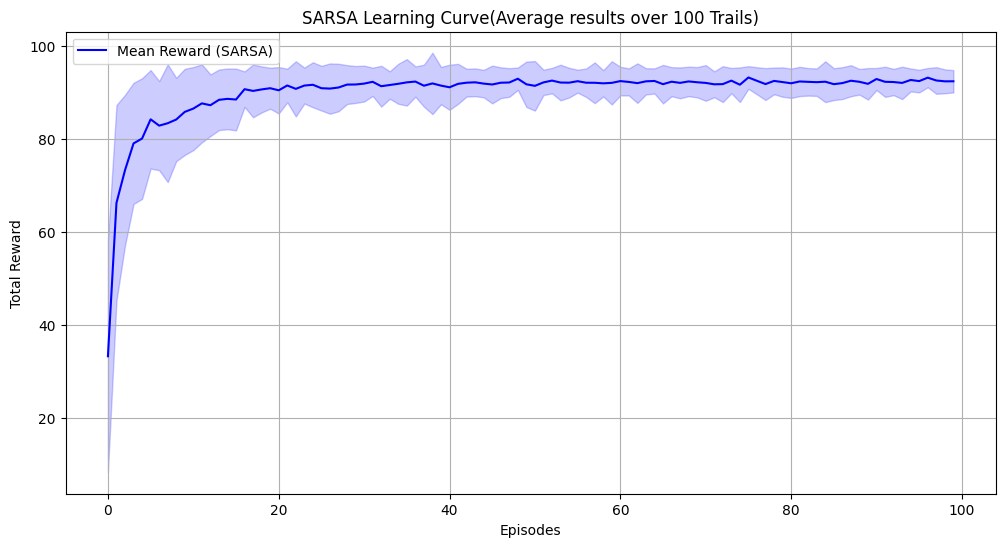

In [204]:
def sarsa(alpha=0.1, gamma=0.95, epsilon=0.1, episodes=100, trials=100):
    rewards = []
    for _ in range(trials):
        Q = {}
        episode_rewards = []
        for _ in range(episodes):
            state = (0, 0, 0, 0)
            if state not in Q:
                Q[state] = {a: 0 for a in actions}

            action = epsilon_greedy(Q, state, epsilon)
            total_reward = 0
            while state[:2] != (3, 3):
                next_state_probs = transition(state, action)
                next_state = random.choices(list(next_state_probs.keys()), weights=next_state_probs.values())[0]
                if next_state not in Q:
                    Q[next_state] = {a: 0 for a in actions}

                next_action = epsilon_greedy(Q, next_state, epsilon)
                reward = get_reward(next_state)
                Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
                state, action = next_state, next_action
                total_reward += reward
            episode_rewards.append(total_reward)
        rewards.append(episode_rewards)
    return np.array(rewards)

# Run SARSA and plot results
rewards = sarsa()
mean_rewards = np.mean(rewards, axis=0)
std_rewards = np.std(rewards, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(mean_rewards, label="Mean Reward (SARSA)", color='b')
plt.fill_between(range(len(mean_rewards)), mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2, color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("SARSA Learning Curve(Average results over 100 Trails)")
plt.legend()
plt.grid(True)
plt.show()

In [205]:
def sarsa(alpha=0.1, gamma=0.95, epsilon=0.1, episodes=100, trials=100):
    rewards_matrix = np.zeros((trials, episodes))

    for trial in range(trials):
        Q = {}
        for episode in range(episodes):
            state = (0, 0, 0, 0)
            if state not in Q:
                Q[state] = {a: 0 for a in actions}

            action = epsilon_greedy(Q, state, epsilon)
            total_reward = 0
            while state[:2] != (3, 3):
                next_state_probs = transition(state, action)
                next_state = random.choices(list(next_state_probs.keys()), weights=next_state_probs.values())[0]
                if next_state not in Q:
                    Q[next_state] = {a: 0 for a in actions}

                next_action = epsilon_greedy(Q, next_state, epsilon)
                reward = get_reward(next_state)
                Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
                state, action = next_state, next_action
                total_reward += reward
            rewards_matrix[trial, episode] = total_reward

    mean_rewards = np.mean(rewards_matrix, axis=0)
    std_rewards = np.std(rewards_matrix, axis=0)
    return mean_rewards, std_rewards

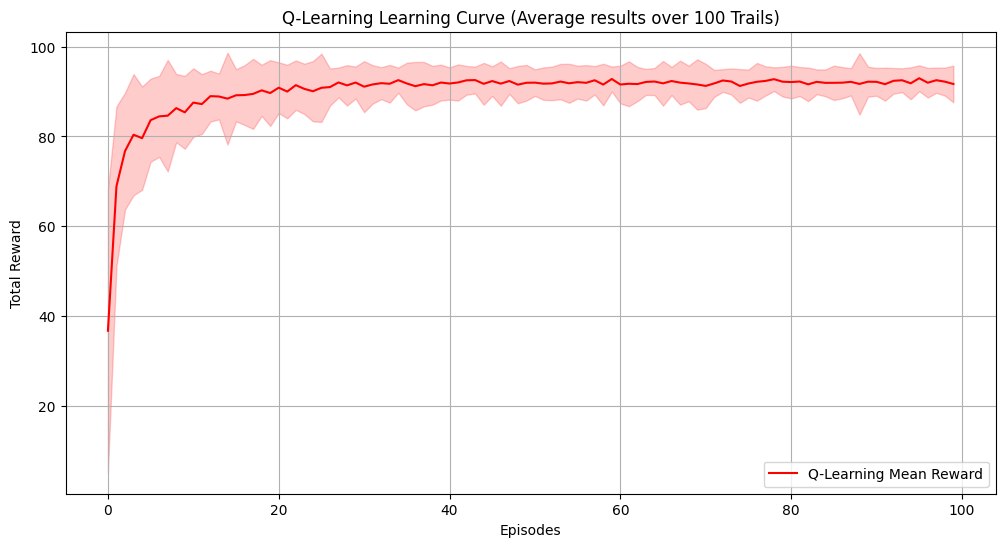

In [207]:
def q_learning(alpha=0.1, gamma=0.95, epsilon=0.1, episodes=100, trials=100):
    rewards_matrix = np.zeros((trials, episodes))

    for trial in range(trials):
        Q = {}  # Initialize Q-table dynamically
        for episode in range(episodes):
            state = (0, 0, 0, 0)  # Start state
            if state not in Q:
                Q[state] = {a: 0 for a in actions}

            total_reward = 0
            while state[:2] != (3, 3):  # Until reaching goal
                action = epsilon_greedy(Q, state, epsilon)
                next_state_probs = transition(state, action)
                next_state = random.choices(list(next_state_probs.keys()), weights=next_state_probs.values())[0]

                if next_state not in Q:
                    Q[next_state] = {a: 0 for a in actions}

                reward = get_reward(next_state)

                # Q-Learning TD Update (Greedy Update)
                Q[state][action] += alpha * (reward + gamma * max(Q[next_state].values()) - Q[state][action])

                state = next_state
                total_reward += reward

            rewards_matrix[trial, episode] = total_reward

    mean_rewards = np.mean(rewards_matrix, axis=0)
    std_rewards = np.std(rewards_matrix, axis=0)
    return mean_rewards, std_rewards

# Run Q-Learning and plot results
mean_rewards, std_rewards = q_learning()
plt.figure(figsize=(12, 6))
plt.plot(range(len(mean_rewards)), mean_rewards, label="Q-Learning Mean Reward", color='red')
plt.fill_between(range(len(mean_rewards)), mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2, color='red')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-Learning Learning Curve (Average results over 100 Trails)")
plt.legend()
plt.grid(True)
plt.show()

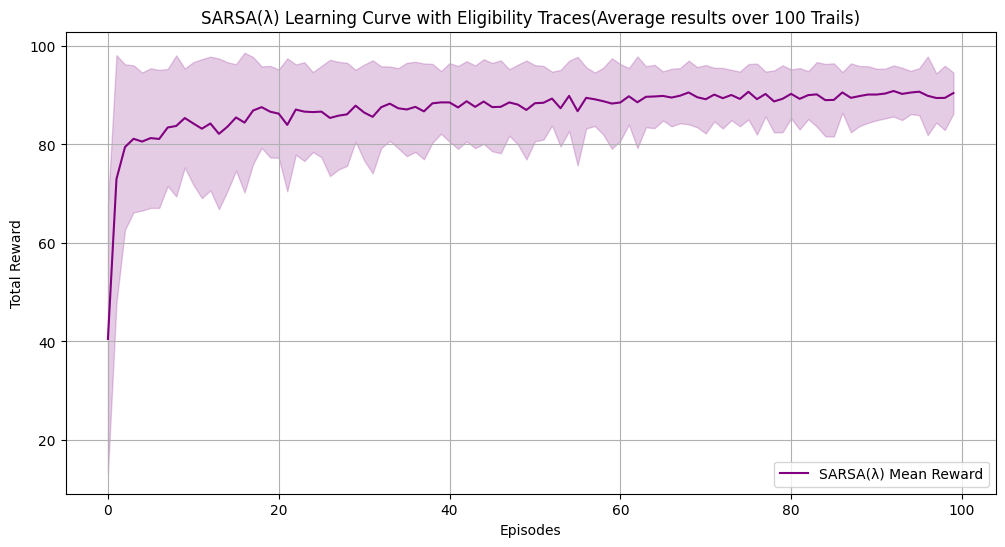

In [214]:
def sarsa_lambda(alpha=0.1, gamma=0.95, epsilon=0.1, lam=0.9, episodes=100, trials=100):
    rewards_matrix = np.zeros((trials, episodes))

    for trial in range(trials):
        Q = {}  # Initialize Q-table dynamically
        for episode in range(episodes):
            state = (0, 0, 0, 0)  # Start state
            if state not in Q:
                Q[state] = {a: 0 for a in actions}

            action = epsilon_greedy(Q, state, epsilon)
            E = {}  # Eligibility traces (dynamic initialization)

            total_reward = 0
            while state[:2] != (3, 3):  # Until reaching the goal
                if state not in E:
                    E[state] = {a: 0 for a in actions}

                next_state_probs = transition(state, action)
                next_state = random.choices(list(next_state_probs.keys()), weights=next_state_probs.values())[0]

                if next_state not in Q:
                    Q[next_state] = {a: 0 for a in actions}
                if next_state not in E:
                    E[next_state] = {a: 0 for a in actions}

                next_action = epsilon_greedy(Q, next_state, epsilon)
                reward = get_reward(next_state)

                # Compute TD Error
                delta = reward + gamma * Q[next_state][next_action] - Q[state][action]

                # Update eligibility trace
                E[state][action] += 1

                # Update Q-values for all states using eligibility traces
                for s in E:
                    for a in actions:
                        Q[s][a] += alpha * delta * E[s][a]  # Q update using eligibility trace
                        E[s][a] *= gamma * lam  # Decay eligibility traces

                state, action = next_state, next_action
                total_reward += reward

            rewards_matrix[trial, episode] = total_reward

    mean_rewards = np.mean(rewards_matrix, axis=0)
    std_rewards = np.std(rewards_matrix, axis=0)
    return mean_rewards, std_rewards

# Run SARSA(λ) and plot results
mean_rewards, std_rewards = sarsa_lambda()
plt.figure(figsize=(12, 6))
plt.plot(range(len(mean_rewards)), mean_rewards, label="SARSA(λ) Mean Reward", color='purple')
plt.fill_between(range(len(mean_rewards)), mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2, color='purple')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("SARSA(λ) Learning Curve with Eligibility Traces(Average results over 100 Trails)")
plt.legend()
plt.grid(True)
plt.show()

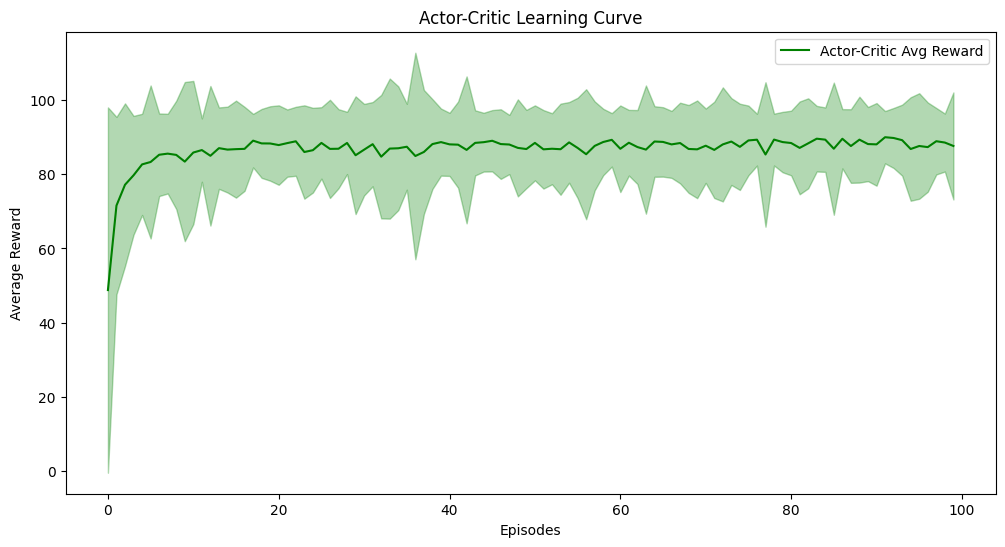

In [199]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define the Gridworld environment
actions = {'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)}
slips = {'up': ['left', 'right'], 'down': ['right', 'left'], 'left': ['down', 'up'], 'right': ['up', 'down']}

# Define all possible states in the grid
state_space = [(x, y, w, f) for x in range(4) for y in range(4) for w in [0, 1] for f in [0, 1]]

def run_actor_critic(episodes=100, trials=100, alpha=0.1, beta=0.1, gamma=0.95, lambda_=0.8):
    rewards_matrix = np.zeros((trials, episodes))

    for trial in range(trials):
        theta = np.random.randn(len(state_space) * len(actions))
        w = np.zeros(len(state_space) * len(actions))

        for episode in range(episodes):
            state = (0, 0, 0, 0)
            total_reward = 0

            while state[:2] != (3, 3):
                action = random.choice(list(actions.keys()))
                transitions = transition(state, action)
                next_state = random.choices(list(transitions.keys()), weights=list(transitions.values()))[0]
                reward = get_reward(next_state)

                state_feature = feature_function(state, action)
                next_action = random.choice(list(actions.keys()))
                next_state_feature = feature_function(next_state, next_action)

                delta = reward + gamma * np.dot(w, next_state_feature) - np.dot(w, state_feature)

                w += alpha * delta * state_feature
                theta += beta * delta * state_feature

                state = next_state
                total_reward += reward

            rewards_matrix[trial, episode] = total_reward

    mean_rewards = np.mean(rewards_matrix, axis=0)
    std_rewards = np.std(rewards_matrix, axis=0)
    return mean_rewards, std_rewards

# Define feature function for function approximation
def feature_function(state, action):
    """Returns feature vector for a given (state, action) pair."""
    features = np.zeros(len(state_space) * len(actions))  # One-hot encoding
    state_idx = state_space.index(state) if state in state_space else 0  # Ensure state exists
    action_idx = list(actions.keys()).index(action)
    features[state_idx * len(actions) + action_idx] = 1  # Encode (state, action)
    return features

# Softmax policy for action selection
def softmax_policy(state, theta):
    """Returns action probabilities using a softmax policy."""
    action_values = np.array([np.dot(theta, feature_function(state, action)) for action in actions])
    exp_values = np.exp(action_values - np.max(action_values))  # Avoid overflow
    return exp_values / np.sum(exp_values)

# Actor-Critic with function approximation
def run_actor_critic(trials=100, episodes=100, alpha=0.1, beta=0.1, gamma=0.95, lambda_=0.8):
    rewards_matrix = np.zeros((trials, episodes))

    for trial in tqdm(range(trials), desc="Running Actor-Critic Trials"):
        theta = np.random.randn(len(state_space) * len(actions))  # Actor weights
        w = np.zeros(len(state_space) * len(actions))  # Critic weights

        for episode in range(episodes):
            state = (0, 0, 0, 0)  # Start state
            eligibility_trace_w = np.zeros(len(state_space) * len(actions))  # Critic eligibility trace
            eligibility_trace_theta = np.zeros(len(theta))  # Actor eligibility trace
            total_reward = 0

            while state[:2] != (3, 3):  # Until goal is reached
                probs = softmax_policy(state, theta)
                action = np.random.choice(list(actions.keys()), p=probs)
                transitions = transition(state, action)
                next_state = random.choices(list(transitions.keys()), weights=list(transitions.values()))[0]
                reward = get_reward(next_state)

                # Compute TD error
                delta = reward + gamma * np.dot(w, feature_function(next_state, action)) - np.dot(w, feature_function(state, action))

                # Critic update
                eligibility_trace_w = gamma * lambda_ * eligibility_trace_w + feature_function(state, action)
                w += alpha * delta * eligibility_trace_w

                # Actor update
                eligibility_trace_theta = gamma * lambda_ * eligibility_trace_theta + feature_function(state, action)
                theta += beta * delta * eligibility_trace_theta

                state = next_state
                total_reward += reward

            rewards_matrix[trial, episode] = total_reward

    return np.mean(rewards_matrix, axis=0), np.std(rewards_matrix, axis=0)



# Plot Actor-Critic Learning Curve
plt.figure(figsize=(12, 6))
plt.plot(range(100), mean_actor_critic, label="Actor-Critic Avg Reward", color='green')
plt.fill_between(range(100), mean_actor_critic - std_actor_critic, mean_actor_critic + std_actor_critic, alpha=0.3, color='green')
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Actor-Critic Learning Curve")
plt.legend()
plt.show()

Running Actor-Critic Trials: 100%|██████████| 100/100 [00:17<00:00,  5.69it/s]


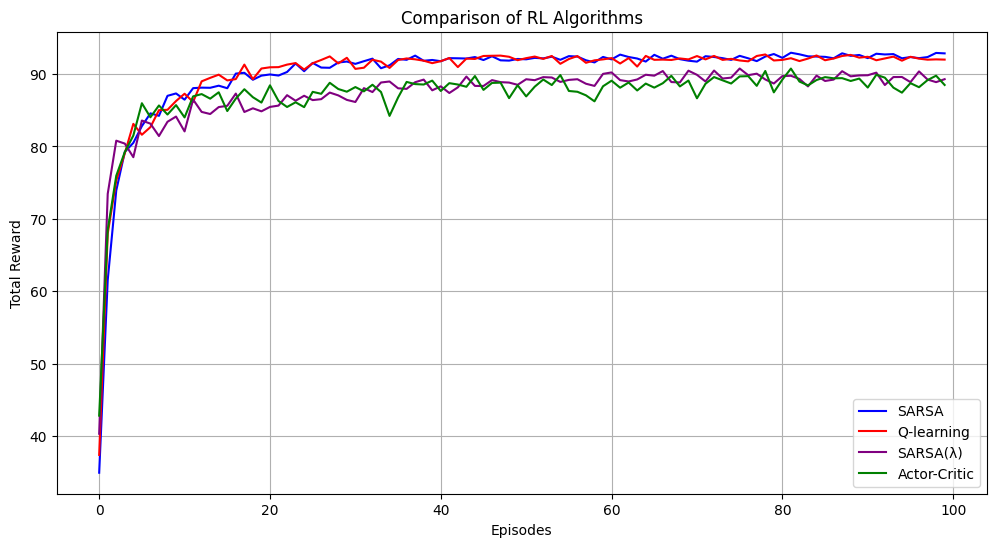

In [201]:
def compare_algorithms():
    mean_sarsa_rewards, std_sarsa_rewards = sarsa()
    mean_q_learning_rewards, std_q_learning_rewards = q_learning()
    mean_sarsa_lambda_rewards, std_sarsa_lambda_rewards = sarsa_lambda()
    mean_actor_critic_rewards, std_actor_critic_rewards = run_actor_critic()

    plt.figure(figsize=(12, 6))
    plt.plot(mean_sarsa_rewards, label='SARSA', color='blue')
    plt.plot(mean_q_learning_rewards, label='Q-learning', color='red')
    plt.plot(mean_sarsa_lambda_rewards, label='SARSA(λ)', color='purple')
    plt.plot(mean_actor_critic_rewards, label='Actor-Critic', color='green')


    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title('Comparison of RL Algorithms')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison function
compare_algorithms()